![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [25]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [26]:
nldi = NLDI()
usgs_gage_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
WY = 2019 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

Collect watershed and reach vectors using the pynhd module.

In [27]:
#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file("files/TuolumneRiverBasin.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

Create and interactive map to display the watershed.

In [ ]:
# create map, having trouble showigng the map? Does "Make this Notebook Trusted to load map" appear?
#cd to the directy and run jupyter trust Snotel.ipynb
mapping.basin_mapping(basin, site_feature)

![Basin](./images/basin.png)

# 2. Identify SNOTEL sites within a spatial domain

Here, we will read a geojson file from the web containing the geospatial information for all SNOTEL sites. 
Once loaded, the script will use the basin geometry (in the form of a polygon in the GeoDataFrame) to clip all SNOTEL sites located within the boundaries of the basin.

In [28]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry.iloc[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,TUM,Tuolumne Meadows,CCSS,2621.280,37.876406,-119.348096,California,180400090102,11SKB,Sierra Nevada,2004-10-01,2026-03-15,True,POINT (-119.3481 37.87641)
1,TES,Tioga Pass Entry Station,CCSS,3031.236,37.910870,-119.258507,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-14,True,POINT (-119.25851 37.91087)
2,DAN,Dana Meadows,CCSS,2987.040,37.896162,-119.257260,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-15,True,POINT (-119.25726 37.89616)
3,SLI,Slide Canyon,CCSS,2804.160,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-03-15,True,POINT (-119.43188 38.09123)


Add the SNOTEL monitoring station locations to the map

In [ ]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

![basinsnotel](./images/basinsnotel.png)

# 3. Retrieve data for the selected sites

The following uses the [getData.py](./supporting_scripts/getData.py) script to download SNOTEL data for the sites within the domain. Inputs to this script include the SNOTEL site name, site ID, and state abbreviation, which are retrieved from the geodataframe above. Additional inputs include the start and end dates, as well as the path to save the outputs.

In [29]:
# Use the getData module to retrieve data 
OutputFolder = 'files/SNOTEL'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

for i in gdf_in_bbox.index:
    getData.getCaliSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)
    #getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)


Start retrieving data for Tuolumne Meadows, TUM
https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/TUM:CA:MSNT%257Cid=%2522%2522%257Cname/2004-10-01,2026-03-15/WTEQ::value?fitToScreen=false
Status: 200
Data decoded from bytes to string
Start retrieving data for Tioga Pass Entry Station, TES
https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/TES:CA:MSNT%257Cid=%2522%2522%257Cname/2004-10-01,2026-03-14/WTEQ::value?fitToScreen=false
Status: 200
Data decoded from bytes to string
Start retrieving data for Dana Meadows, DAN
https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/DAN:CA:MSNT%257Cid=%2522%2522%257Cname/2004-10-01,2026-03-15/WTEQ::value?fitToScreen=false
Status: 200
Data decoded from bytes to string
Start retrieving data for Slide Canyon, SLI
https://wcc.sc.egov.usda.gov/reportGenerato

# 4.  Process the data to enable plotting and analysis

In [30]:

# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'Ca'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

sitedict['TUM'].head()

TUM
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
TES
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
2019 not found in the data, not dropping any columns
DAN
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
SLI
Dropping 2019 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site


,M,D,2005_SWE_in,2006_SWE_in,2007_SWE_in,2008_SWE_in,2009_SWE_in,2010_SWE_in,2011_SWE_in,2012_SWE_in,...,2022_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-10-05


# 5. Make a snow report for WY2019

We use the script [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **SNOTELPlots()** function to generate a plot of all snotel sites of interest. The function takes in the following inputs:
* A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* geodataframe with a bounding box from the above step
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

In [ ]:
watershed = "Tuolumne"
AOI = 'Above Hetch Hetchy Reservoir'
DOI = '03-01' #must be in MM-DD form
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)

# 6. Generate a Basin Snow report

By using the [SNOTEL_Analyzer](./supporting_scripts/SNOTEL_Analyzer.py) **catchmentSNOTELAnalysis()** function, the user will be able to develop a statistical snow analysis based on the mean values of each SNOTEL observation station within the catchment.

The function takes in the following inputs:
**A dictionary of sites - if you only have one site, that is fine but it still needs to be in a dictionary
* A water year (WY) of interest
* An Area of Interest (AOI) name
* Day of interest (DOI). This makes the dashed vline and establishes the statistics

In [ ]:
watershed = "Tuolumne"
AOI = 'Above Hetch Hetchy Reservoir'
DOI = '04-01' #must be in MM-DD form

SNOTEL_Analyzer.catchmentSNOTELAnalysis(sitedict, WY, watershed, AOI, DOI)

## Getting additional data, Lets go from Snow to Flow!

Lets grab streamflow data using the USGS NWIS Data retrieval script and the dates of SNOTEL data





In [31]:
#use the dates for snotel data availability
gdf_in_bbox.head()

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,TUM,Tuolumne Meadows,CCSS,2621.280,37.876406,-119.348096,California,180400090102,11SKB,Sierra Nevada,2004-10-01,2026-03-15,True,POINT (-119.3481 37.87641)
1,TES,Tioga Pass Entry Station,CCSS,3031.236,37.910870,-119.258507,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-14,True,POINT (-119.25851 37.91087)
2,DAN,Dana Meadows,CCSS,2987.040,37.896162,-119.257260,California,180400090102,11SLB,Sierra Nevada,2004-10-01,2026-03-15,True,POINT (-119.25726 37.89616)
3,SLI,Slide Canyon,CCSS,2804.160,38.091234,-119.431881,California,180400090501,11SKC,Sierra Nevada,2005-10-01,2026-03-15,True,POINT (-119.43188 38.09123)


In [32]:
gdf_in_bbox.beginDate.max()

'2005-10-01'

In [37]:
begin = gdf_in_bbox.beginDate.max()
end = gdf_in_bbox.endDate.min()
streamflow = getData.get_usgs_streamflow(usgs_gage_id, begin, end)

Retrieving data for Site: 11274790 from 2005-10-01 to 2026-03-14...


In [36]:
streamflow.head()

,site_no,00060_Mean,00060_Mean_cd
datetime,,,
2006-10-13 00:00:00+00:00,11274790,21.6,A
2006-10-14 00:00:00+00:00,11274790,19.9,A
2006-10-15 00:00:00+00:00,11274790,19.0,A
2006-10-16 00:00:00+00:00,11274790,17.8,A
2006-10-17 00:00:00+00:00,11274790,17.0,A


## Clean the data

We need to change the index to a datetime indexand clean it to just the date. We do not need the 00060_Mean_cd column, and we should change it to streamflow in cfs

In [38]:
cleaned = dataprocessing.clean_nwis_dataframe(streamflow)
cleaned.head()

,site_no,flow_cfs
2006-10-13,11274790,21.6
2006-10-14,11274790,19.9
2006-10-15,11274790,19.0
2006-10-16,11274790,17.8
2006-10-17,11274790,17.0


## Plot the data


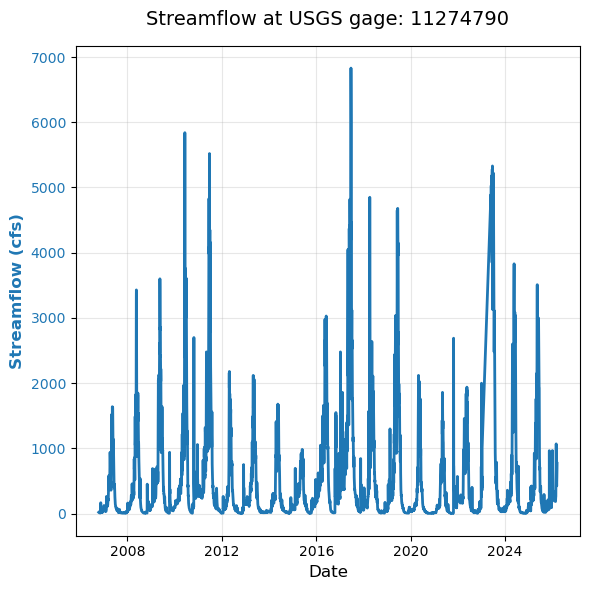

In [39]:
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cfs)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(cleaned.index, cleaned['flow_cfs'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

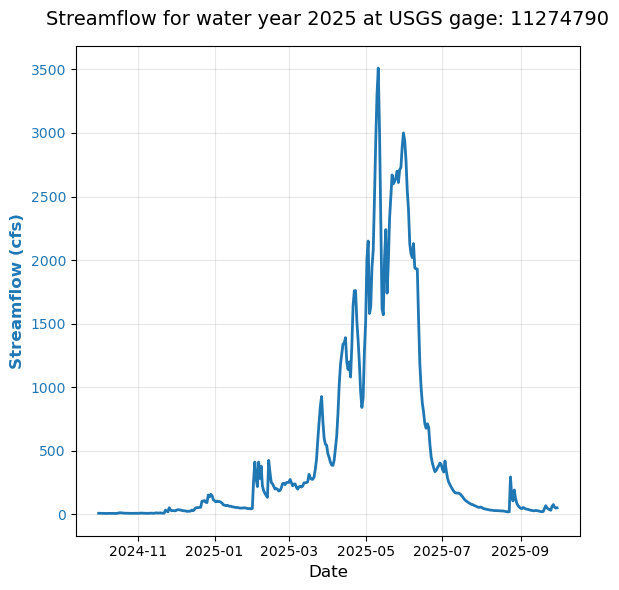

In [40]:
#clip the dataframe to show one single year
WY_df = cleaned.loc['2024-10-01':'2025-09-30']

#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: Streamflow ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Streamflow (cfs)', color='tab:blue', fontsize=12, fontweight='bold')
ax1.plot(WY_df.index, WY_df['flow_cfs'], color='tab:blue', label='Streamflow', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Title and Layout
plt.title('Streamflow for water year 2025 at USGS gage: ' + usgs_gage_id, fontsize=14, pad=15)
fig.tight_layout()
plt.show()

## Get precipitation and temperature data for our area of interest using PyDayMet

In [44]:
cleaned.index[-1].strftime('%Y-%m-%d')  

'2026-03-14'

In [45]:
import earthaccess # note, you may need to create a .netrc file in you home directory with the following information
from pynhd import NLDI
import pydaymet as daymet

# Authenticate with NASA (only needed once per session)
earthaccess.login(persist=True)

# Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id)
geometry = basin.to_crs("EPSG:4326").geometry[0]

var = ["prcp", "tmin", "tmax"]
dates = (cleaned.index[0].strftime('%Y-%m-%d') , cleaned.index[-1].strftime('%Y-%m-%d') ) # Started with a smaller range to test

# Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
daily = daymet.get_bygeom(geometry=geometry, dates=dates, variables=["prcp"], validate_filesize=True)

#Note, there is a problem with the get_bygeom function related to the daymet url. All data has been transfered to NASA EarthData, and the URLs to not work. Point data seems to be working



InputRangeError: Valid range for start/end is from 1980-01-01 00:00:00 to 2025-12-31 00:00:00.

In [46]:
import earthaccess # note, you may need to create a .netrc file in you home directory with the following information
from pynhd import NLDI
import pydaymet as daymet

#Authenticate with NASA (only needed once per session)
earthaccess.login(persist=True)

#Get geometry and ensure CRS is correct
basin = NLDI().get_basins(usgs_gage_id)
geometry_centroid = basin.to_crs("EPSG:4326").geometry[0].centroid
centroid = (geometry_centroid.x, geometry_centroid.y)

var = ["prcp", "tmin", "tmax"]
dates = (cleaned.index[0].strftime('%Y-%m-%d') , cleaned.index[-1].strftime('%Y-%m-%d') ) # Use the streamflow to determine dates

#Fetch data - authentication now happens automatically via earthaccess/.netrc
# Try this simplified call first
met_df = daymet.get_bycoords(centroid, dates, variables=["prcp", "tmin", "tmax"])



In [48]:
# clean the dataframe, rename the columns
met_df.rename(columns={"prcp (mm/day)": " prcp_mm_day", "tmin (degrees C)": "tmin_C", "tmax (degrees C)": "tmax_C"}, inplace=True)
#Calculate Mean Temperature
met_df["tmean"] = (met_df.tmax_C + met_df.tmin_C) / 2

#clip the dataframe by the streamflow dates
met_df = met_df.loc[cleaned.index[0]:cleaned.index[-1]]

met_df.head()


,prcp_mm_day,tmax_C,tmin_C,tmean
time,,,,
2006-10-13,0.0,12.52,0.68,6.600
2006-10-14,0.0,12.76,-0.87,5.945
2006-10-15,0.0,15.72,-0.42,7.650
2006-10-16,0.0,9.39,-3.07,3.160
2006-10-17,0.0,5.66,-5.95,-0.145


## Put it all together into one dataframe

We want to create one data frame containing streamflow, meteological information, and SNOTEL for our period of record

In [64]:
#load snotel data
unprocessed_SNOTEL = {}
#read all files in the following path into the dictionary
path = 'files/SNOTEL'
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        #select the name of the file between the _ and _
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        #make the date a datetime object and set to the index
        unprocessed_SNOTEL[name]['Date'] = pd.to_datetime(unprocessed_SNOTEL[name]['Date'])
        unprocessed_SNOTEL[name].set_index('Date', inplace=True)
        #rename the Snow Water Equivalent (m) Start of Day Values to SWE_in
        unprocessed_SNOTEL[name].rename(columns={'Snow Water Equivalent (m) Start of Day Values': 'SWE_in'}, inplace=True)
        #remove the Water_Year column
        unprocessed_SNOTEL[name].drop(columns=['Water_Year'], inplace=True)
